In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- sky errors
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     379   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        60   (2094, 964)   float32   


In [4]:
image_cut = image[75:175, 0:1890]
image_error_cut = image_error[75:175, 0:1890]

Text(0.5, 0, 'wavelength')

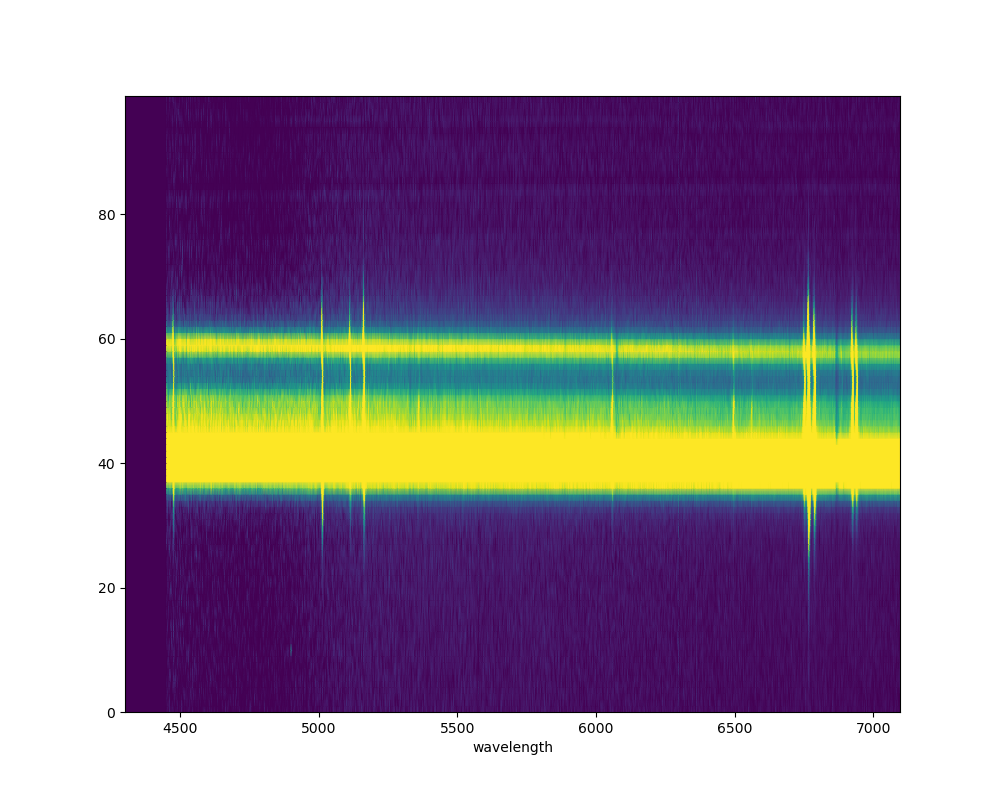

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.03144
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/PSF/Real_seeing_Mrk789.txt")
sigmas = seeing / 2.35
n_component = 3
print(sigmas)

[0.81079758 0.94529828 0.80761288 0.78693189 0.94913518 0.84425532]


In [7]:
l_HA

6769.340719999999

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     379   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        60   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

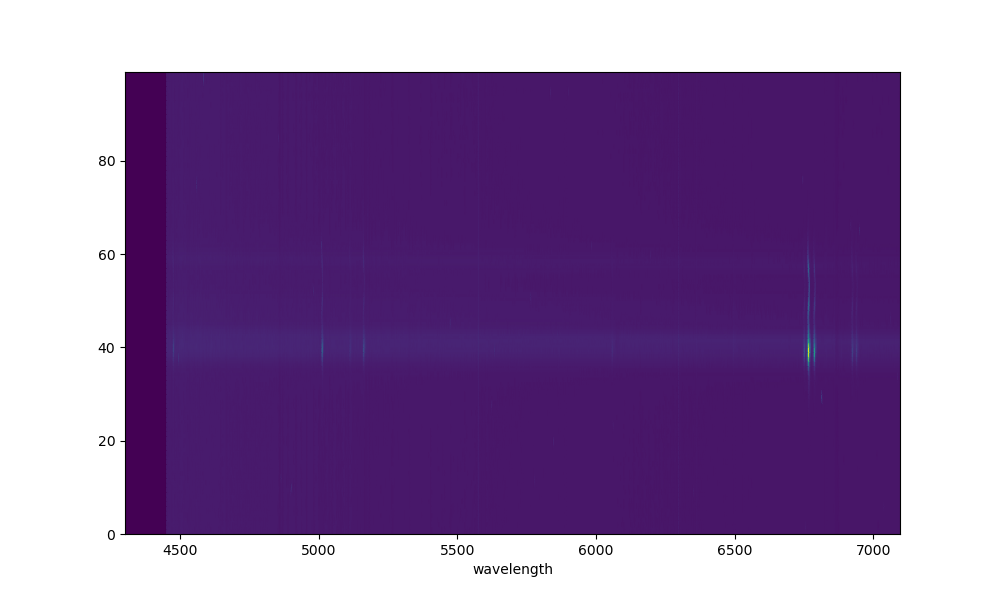

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[75:175, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

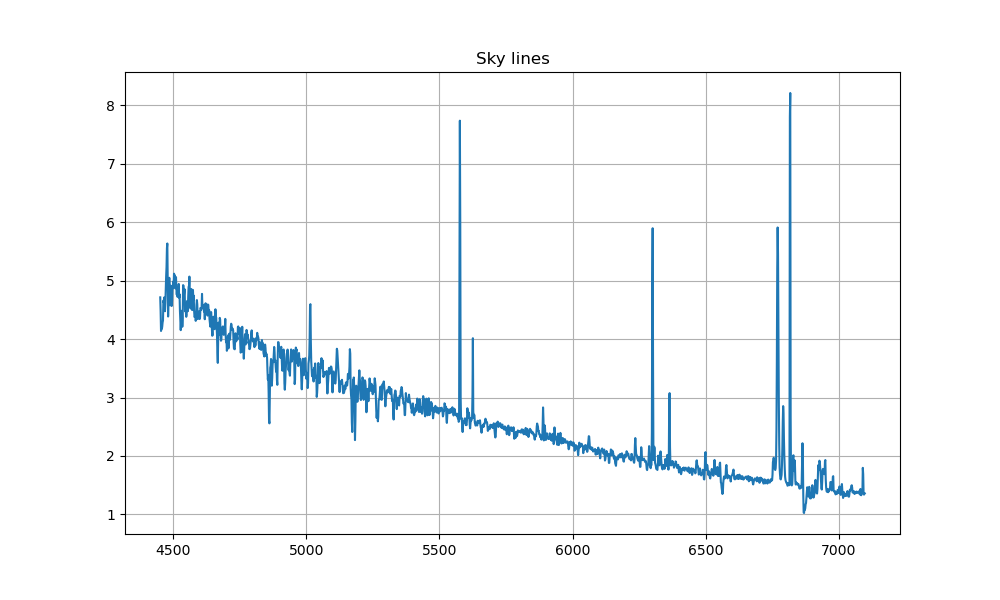

In [9]:
mask_sky = (y > 24)*(y < 34)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

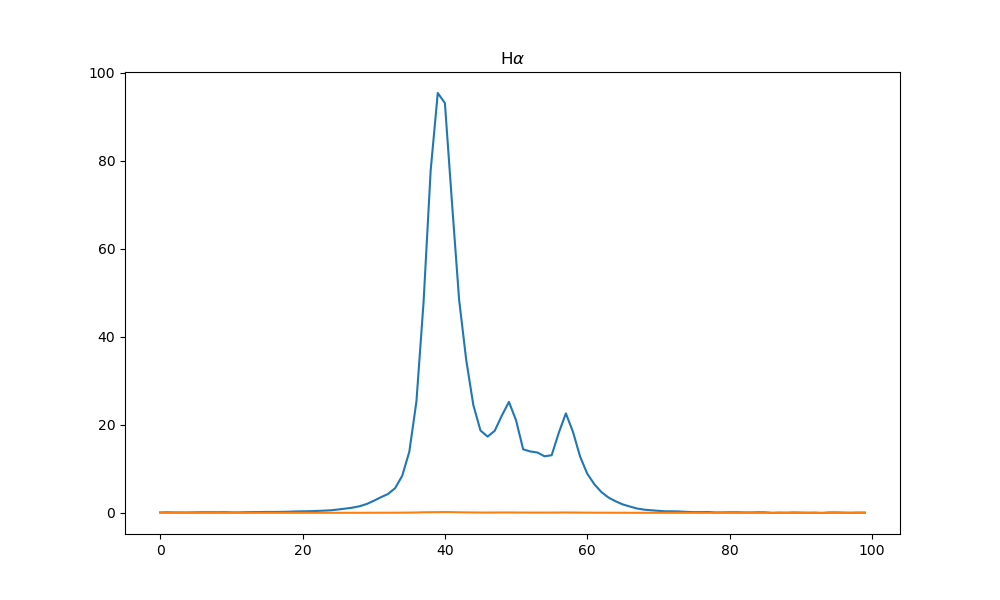

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Propagazione_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [11]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) #+
        #sersic_1d(x_hr, *params[12:16]) #+
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 110)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 110)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 100),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (35, 43),   # x_0: posizione da 0 a 100

    (0, 20),
    (0, 50),
    (0.1, 10),
    (46, 50),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (54, 61)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 233698.87955856897
differential_evolution step 2: f(x)= 79726.2202077924
differential_evolution step 3: f(x)= 16257.51090041149
differential_evolution step 4: f(x)= 13509.626314056817
differential_evolution step 5: f(x)= 13509.626314056817
differential_evolution step 6: f(x)= 13509.626314056817
differential_evolution step 7: f(x)= 8337.553671033867
differential_evolution step 8: f(x)= 8337.553671033867
differential_evolution step 9: f(x)= 3854.6881952530603
differential_evolution step 10: f(x)= 3854.6881952530603
differential_evolution step 11: f(x)= 3854.6881952530603
differential_evolution step 12: f(x)= 3854.6881952530603
differential_evolution step 13: f(x)= 3854.6881952530603
differential_evolution step 14: f(x)= 3495.3644669343216
differential_evolution step 15: f(x)= 1957.9050473108641
differential_evolution step 16: f(x)= 1957.9050473108641
differential_evolution step 17: f(x)= 1957.9050473108641
differential_evolution step 18: f(x)= 1957.90

Sérsic 1: I_e=36.8808, r_e=2.6333, n=0.6963, x_0=39.3940
Sérsic 2: I_e=3.3588, r_e=12.3454, n=1.2163, x_0=48.6062
Sérsic 3: I_e=3.6666, r_e=2.8177, n=1.1334, x_0=57.2519


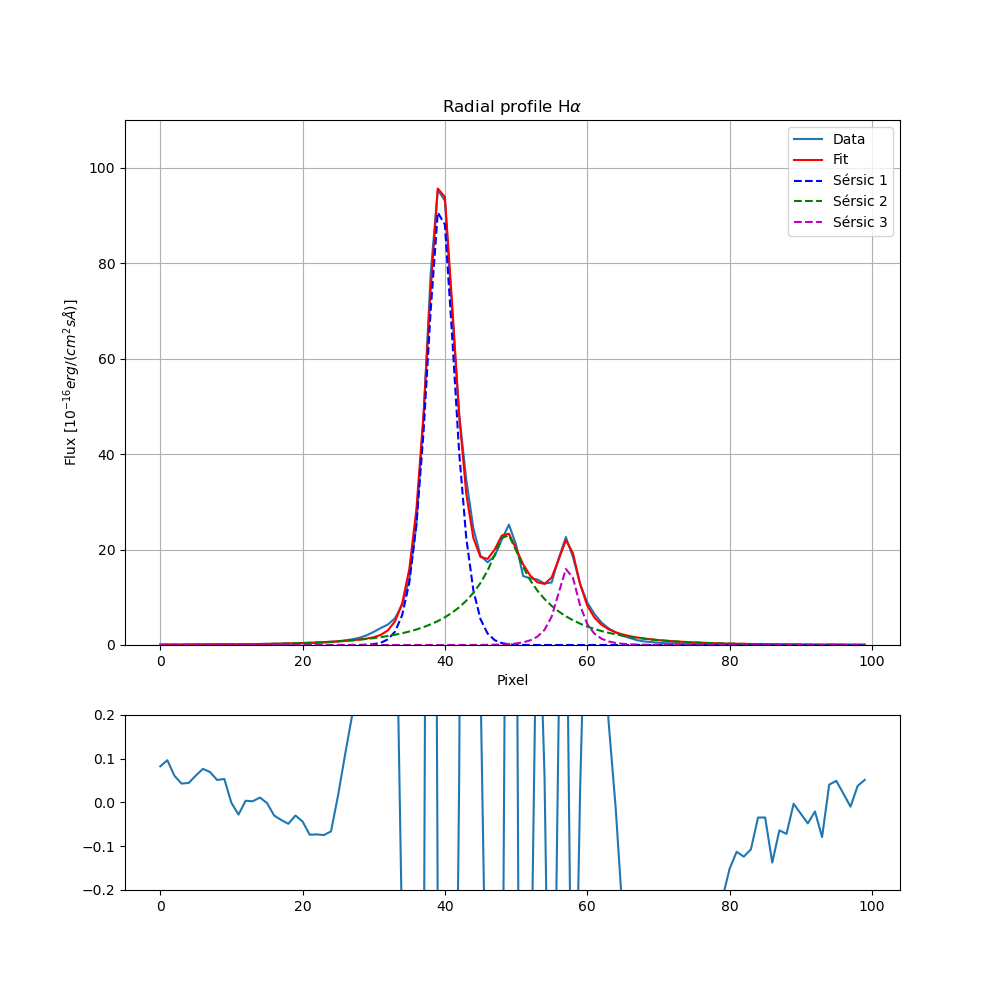

In [13]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [14]:
print(result.x)

[36.88077777  2.633267    0.69632415 39.39400543  3.35879341 12.34539332
  1.21632953 48.60620087  3.66659589  2.81773527  1.13344127 57.25194102]


In [15]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA)#, bounds = bounds_list)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=17.4600, r_e=3.9023, n=1.3285, x_0=39.6501
Sérsic 2: I_e=1.7318, r_e=11.9603, n=1.6745, x_0=48.7751
Sérsic 3: I_e=4.6687, r_e=3.8659, n=0.8977, x_0=57.1218
[1.08798568 0.12167042 0.06271286 0.06243967 0.34219741 0.77678494
 0.16810614 0.13132442 0.45875386 0.26371678 0.08774291 0.12372789]
3.344362459141689


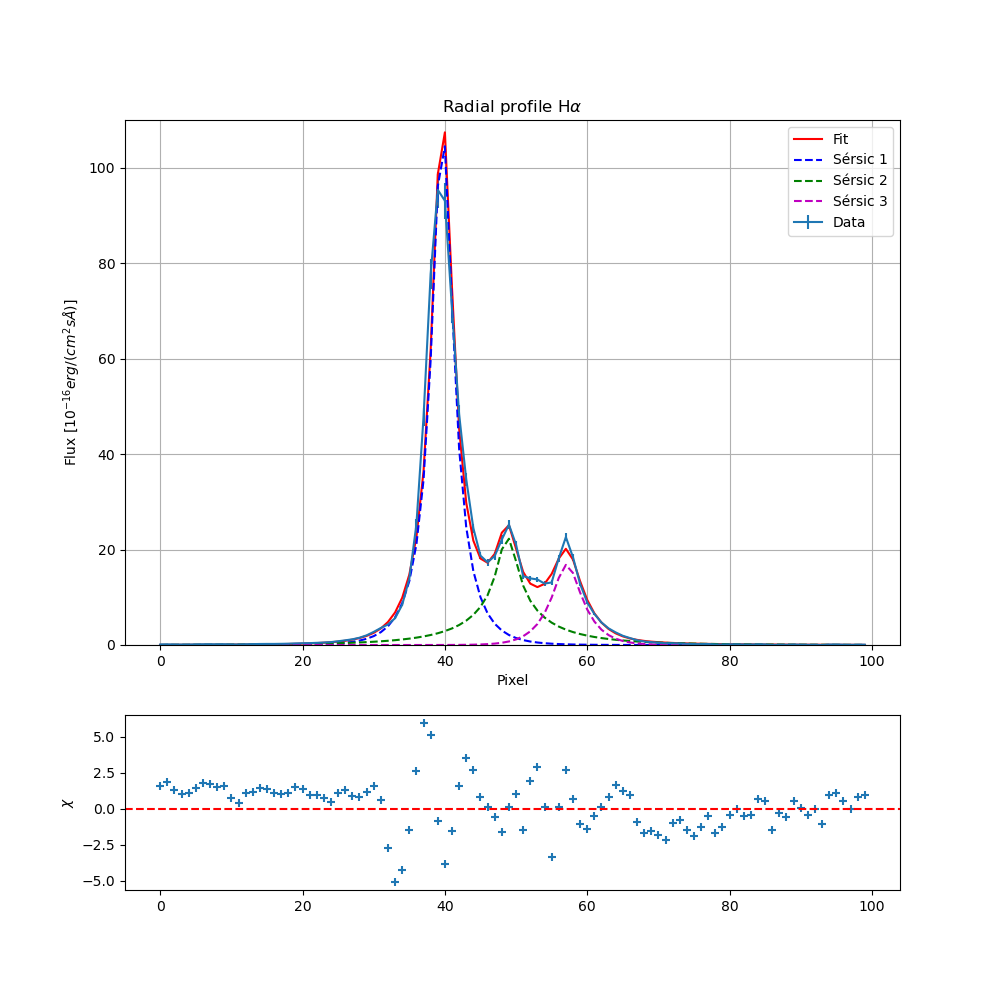

In [16]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [17]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

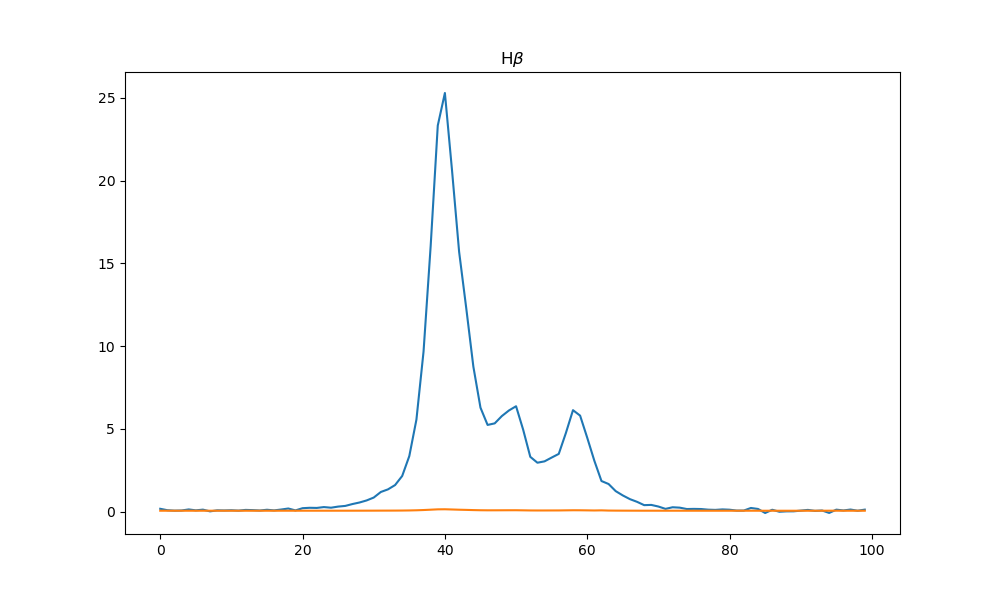

In [18]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[0])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [19]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 32864.26556571108
differential_evolution step 2: f(x)= 971.3206774968749
differential_evolution step 3: f(x)= 971.3206774968749
differential_evolution step 4: f(x)= 776.8878357105622
differential_evolution step 5: f(x)= 433.6446723010458
differential_evolution step 6: f(x)= 433.6446723010458
differential_evolution step 7: f(x)= 433.6446723010458
differential_evolution step 8: f(x)= 433.6446723010458
differential_evolution step 9: f(x)= 155.0054435540841
differential_evolution step 10: f(x)= 155.0054435540841
differential_evolution step 11: f(x)= 155.0054435540841
differential_evolution step 12: f(x)= 155.0054435540841
differential_evolution step 13: f(x)= 155.0054435540841
differential_evolution step 14: f(x)= 155.0054435540841
differential_evolution step 15: f(x)= 155.0054435540841
differential_evolution step 16: f(x)= 155.0054435540841
differential_evolution step 17: f(x)= 155.0054435540841
differential_evolution step 18: f(x)= 155.0054435540841
d

Sérsic 1: I_e=7.9921, r_e=3.0576, n=0.8191, x_0=39.9281
Sérsic 2: I_e=0.5580, r_e=16.8052, n=1.5043, x_0=48.9009
Sérsic 3: I_e=0.9827, r_e=3.5456, n=1.1988, x_0=58.1218


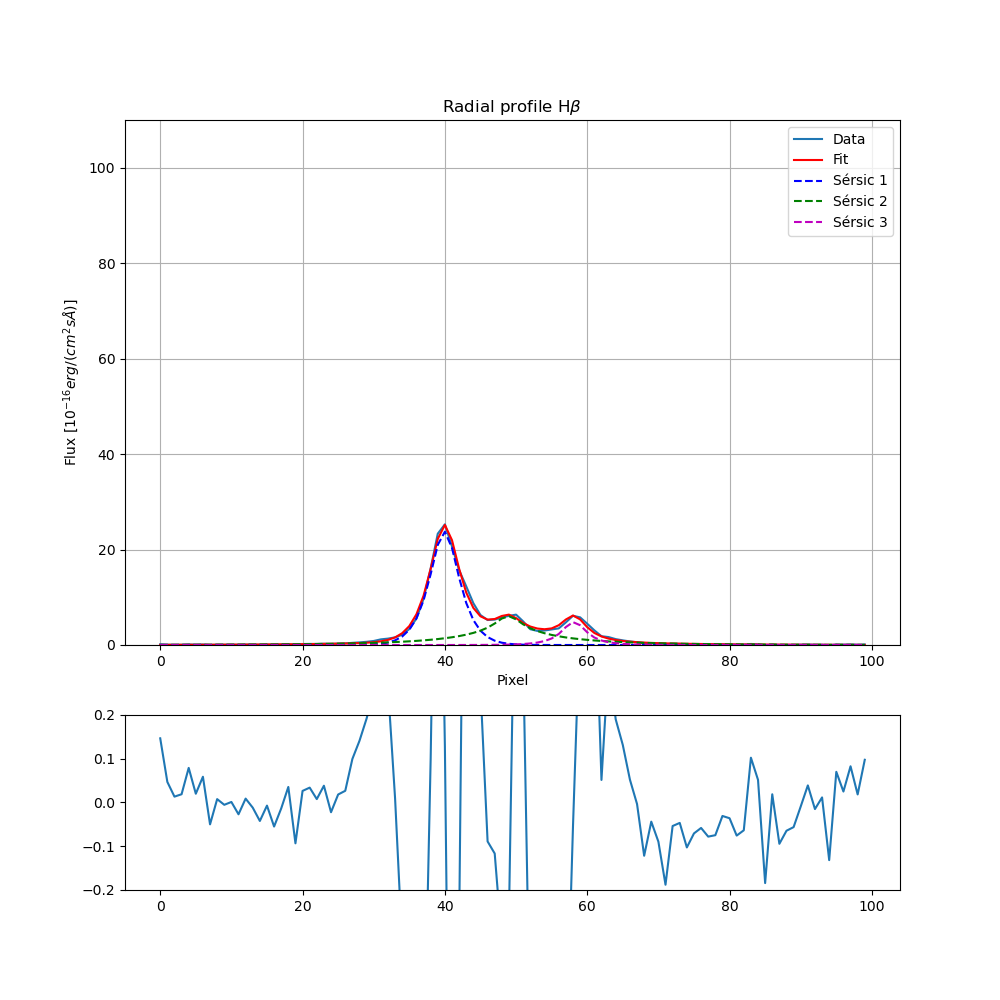

In [20]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [21]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=6.0751, r_e=3.6526, n=1.0350, x_0=40.1612
Sérsic 2: I_e=0.2145, r_e=24.1529, n=2.1591, x_0=49.1326
Sérsic 3: I_e=0.9775, r_e=4.5715, n=1.1719, x_0=58.1218
[0.47697562 0.16431742 0.06888271 0.05748586 0.07739165 4.81519667
 0.27736204 0.13107183 0.22619939 0.77683311 0.17976643 0.10470346]
2.0103948160449345


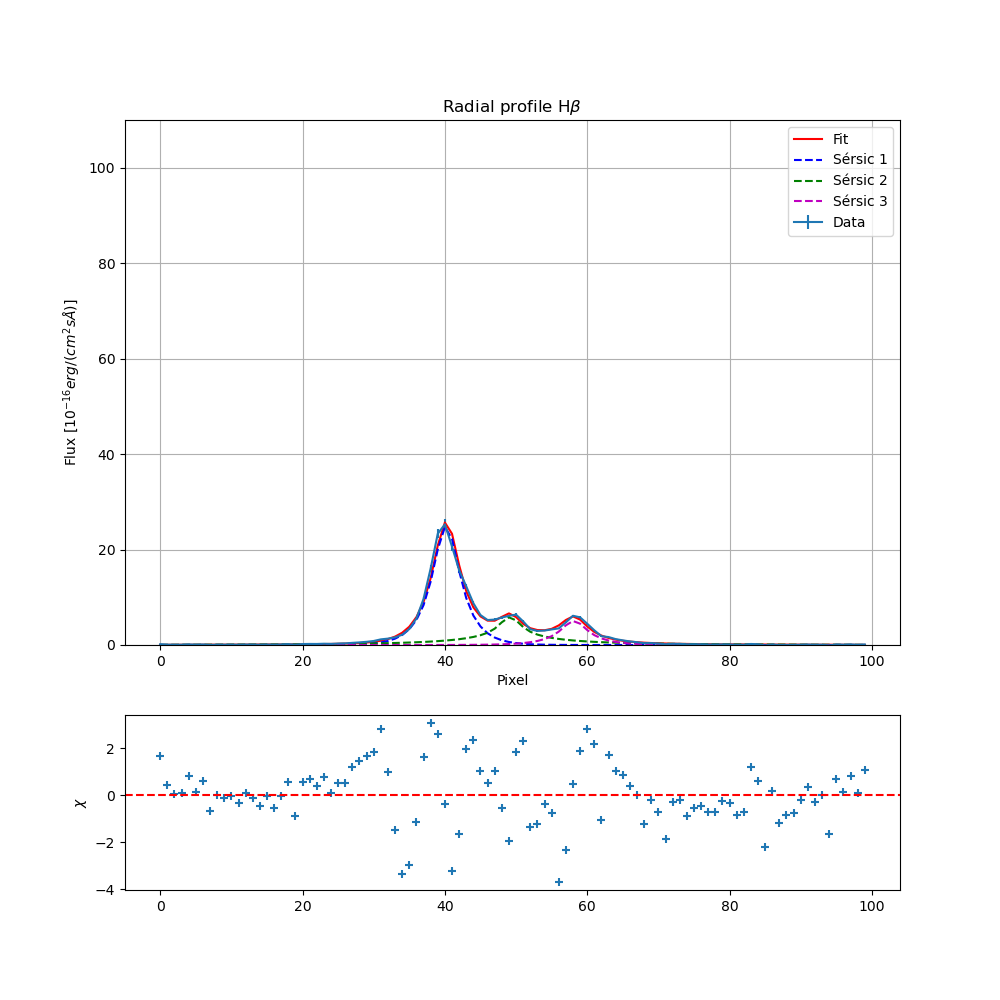

In [22]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

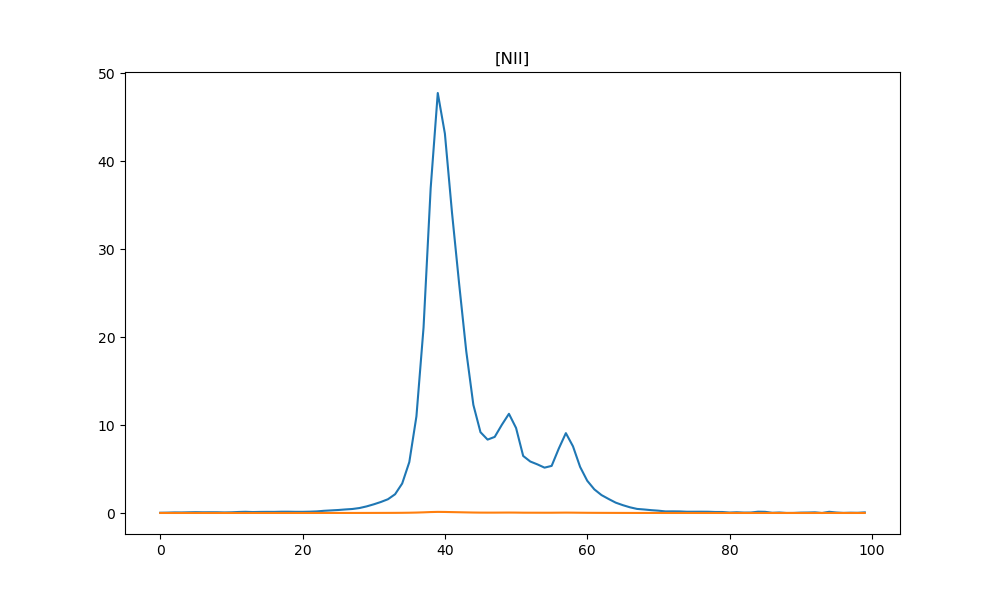

In [23]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [24]:
# Bounds:
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-0.5, x_0_HA[1]+0.5),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-0.5, x_0_HA[2]+0.5),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3506.359752025448
differential_evolution step 2: f(x)= 3506.359752025448
differential_evolution step 3: f(x)= 3506.359752025448
differential_evolution step 4: f(x)= 3506.359752025448
differential_evolution step 5: f(x)= 3506.359752025448
differential_evolution step 6: f(x)= 2747.5886963314533
differential_evolution step 7: f(x)= 1193.3385739020525
differential_evolution step 8: f(x)= 1193.3385739020525
differential_evolution step 9: f(x)= 1193.3385739020525
differential_evolution step 10: f(x)= 1193.3385739020525
differential_evolution step 11: f(x)= 1193.3385739020525
differential_evolution step 12: f(x)= 1193.3385739020525
differential_evolution step 13: f(x)= 1193.3385739020525
differential_evolution step 14: f(x)= 771.9753922632204
differential_evolution step 15: f(x)= 645.7848182766894
differential_evolution step 16: f(x)= 645.7848182766894
differential_evolution step 17: f(x)= 645.7848182766894
differential_evolution step 18: f(x)= 444.0813409

Sérsic 1: I_e=19.3455, r_e=2.4881, n=0.6305, x_0=39.4688
Sérsic 2: I_e=2.1422, r_e=10.9529, n=0.9969, x_0=48.2751
Sérsic 3: I_e=2.1695, r_e=1.8388, n=0.8482, x_0=57.3814


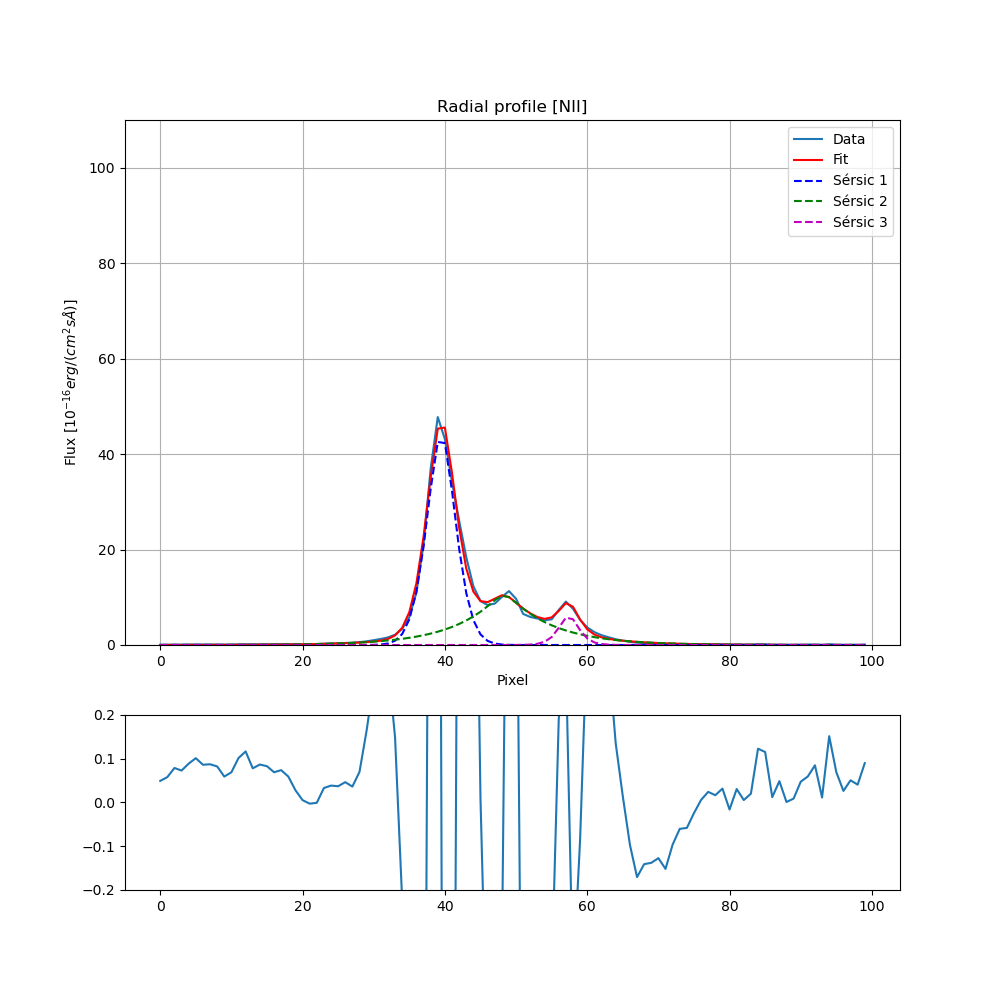

In [25]:
# Plots:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [26]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=14.8742, r_e=2.8711, n=0.8470, x_0=39.7286
Sérsic 2: I_e=1.0043, r_e=13.6603, n=1.4961, x_0=48.5620
Sérsic 3: I_e=1.6406, r_e=3.3060, n=0.9887, x_0=57.3008
[0.80818569 0.07951291 0.04841077 0.05511596 0.16534379 0.84230875
 0.12695557 0.13612883 0.28933572 0.41857337 0.14628287 0.10824626]
2.457125757961958


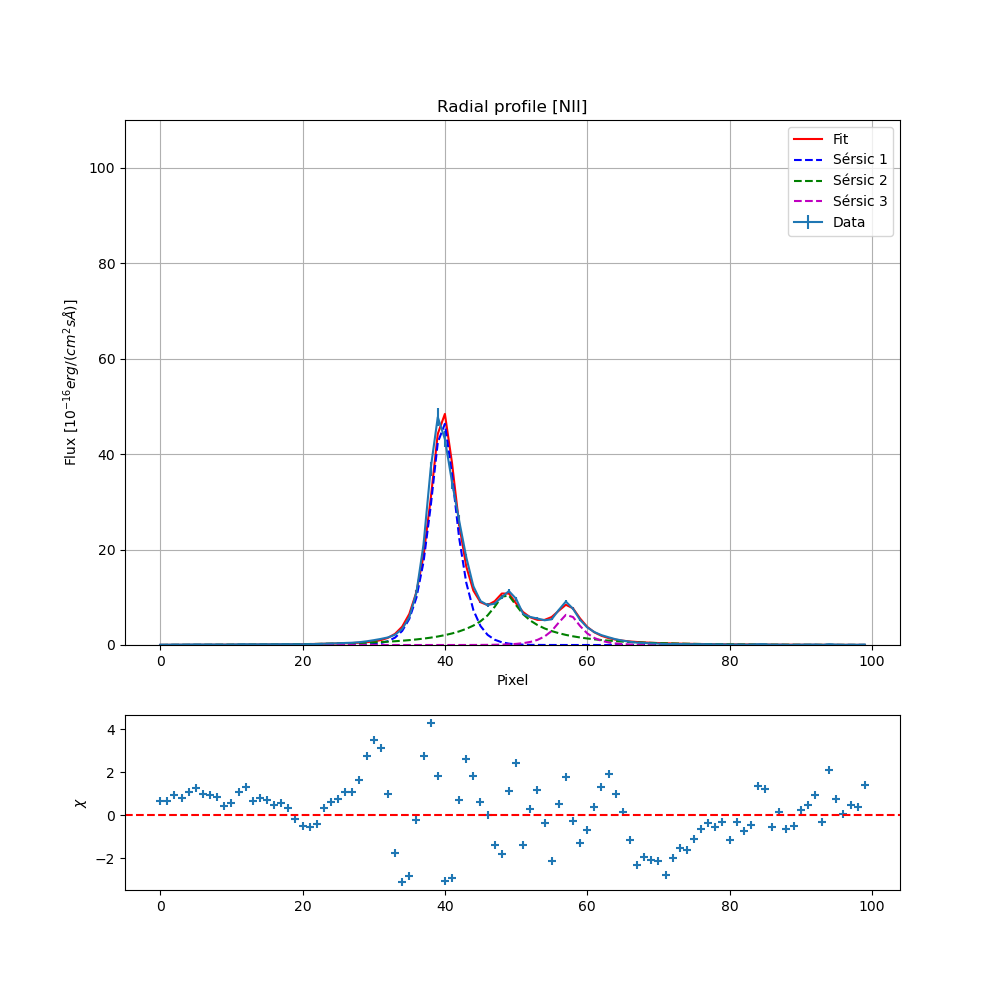

In [27]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

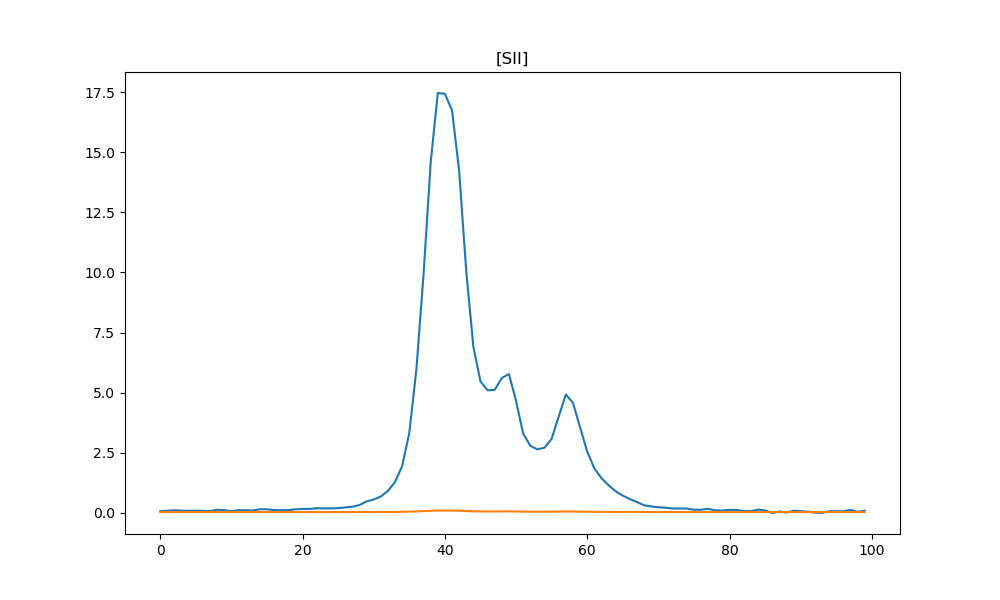

In [28]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[3])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [29]:
# Bounds:
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 4471.745512890873
differential_evolution step 2: f(x)= 1606.6604264795678
differential_evolution step 3: f(x)= 1296.7101033948543
differential_evolution step 4: f(x)= 1296.7101033948543
differential_evolution step 5: f(x)= 1296.7101033948543
differential_evolution step 6: f(x)= 1296.7101033948543
differential_evolution step 7: f(x)= 1296.7101033948543
differential_evolution step 8: f(x)= 726.6494176467605
differential_evolution step 9: f(x)= 726.6494176467605
differential_evolution step 10: f(x)= 726.6494176467605
differential_evolution step 11: f(x)= 238.79260450282592
differential_evolution step 12: f(x)= 238.79260450282592
differential_evolution step 13: f(x)= 238.79260450282592
differential_evolution step 14: f(x)= 238.79260450282592
differential_evolution step 15: f(x)= 238.79260450282592
differential_evolution step 16: f(x)= 238.79260450282592
differential_evolution step 17: f(x)= 238.79260450282592
differential_evolution step 18: f(x)= 198.25

Sérsic 1: I_e=9.3607, r_e=2.7885, n=0.4555, x_0=39.8378
Sérsic 2: I_e=0.5086, r_e=17.2882, n=1.5261, x_0=48.1819
Sérsic 3: I_e=1.1487, r_e=2.8002, n=0.8512, x_0=57.5979


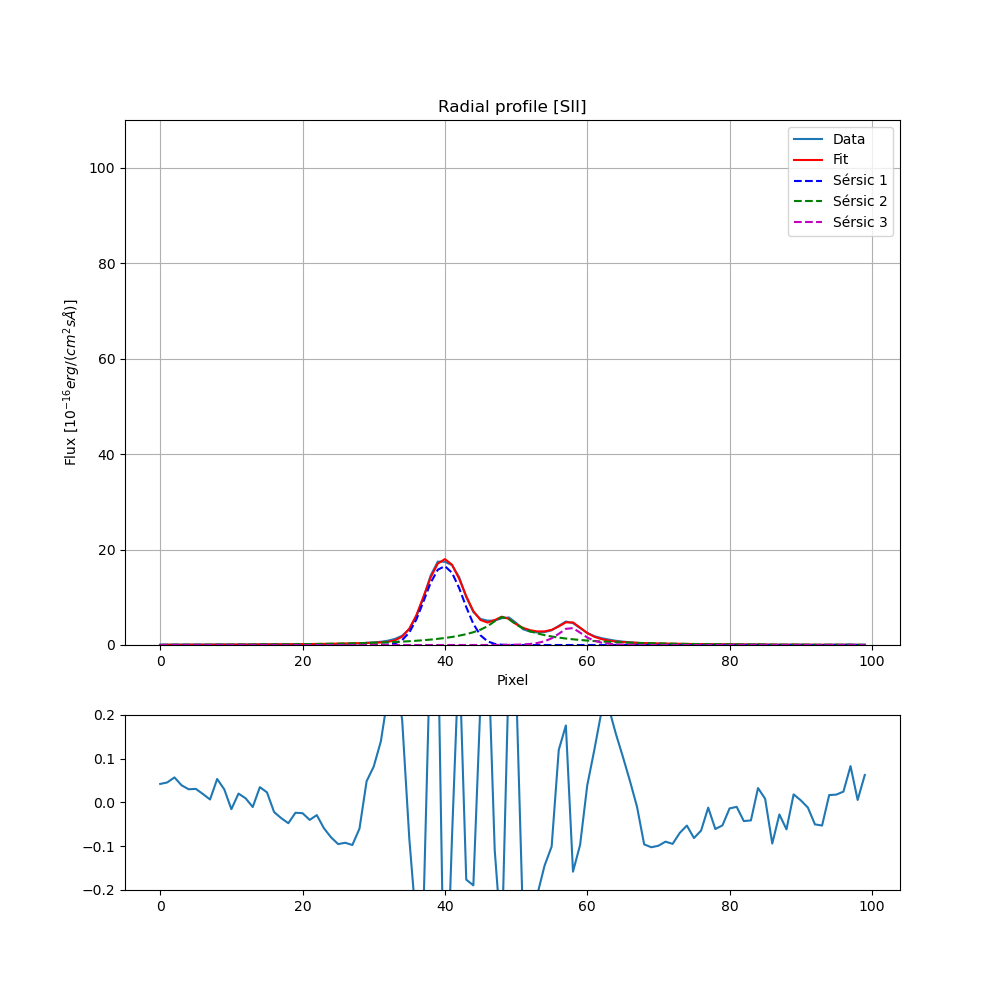

In [30]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [31]:
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=7.4838, r_e=3.1511, n=0.6358, x_0=39.9524
Sérsic 2: I_e=0.3096, r_e=19.7931, n=1.8444, x_0=48.3688
Sérsic 3: I_e=0.8828, r_e=4.0875, n=1.0314, x_0=57.5609
[0.24593522 0.05549564 0.02676857 0.04196529 0.0502167  1.61877259
 0.12035977 0.09012572 0.10798135 0.35729075 0.09479789 0.07278917]
0.9289547640219102


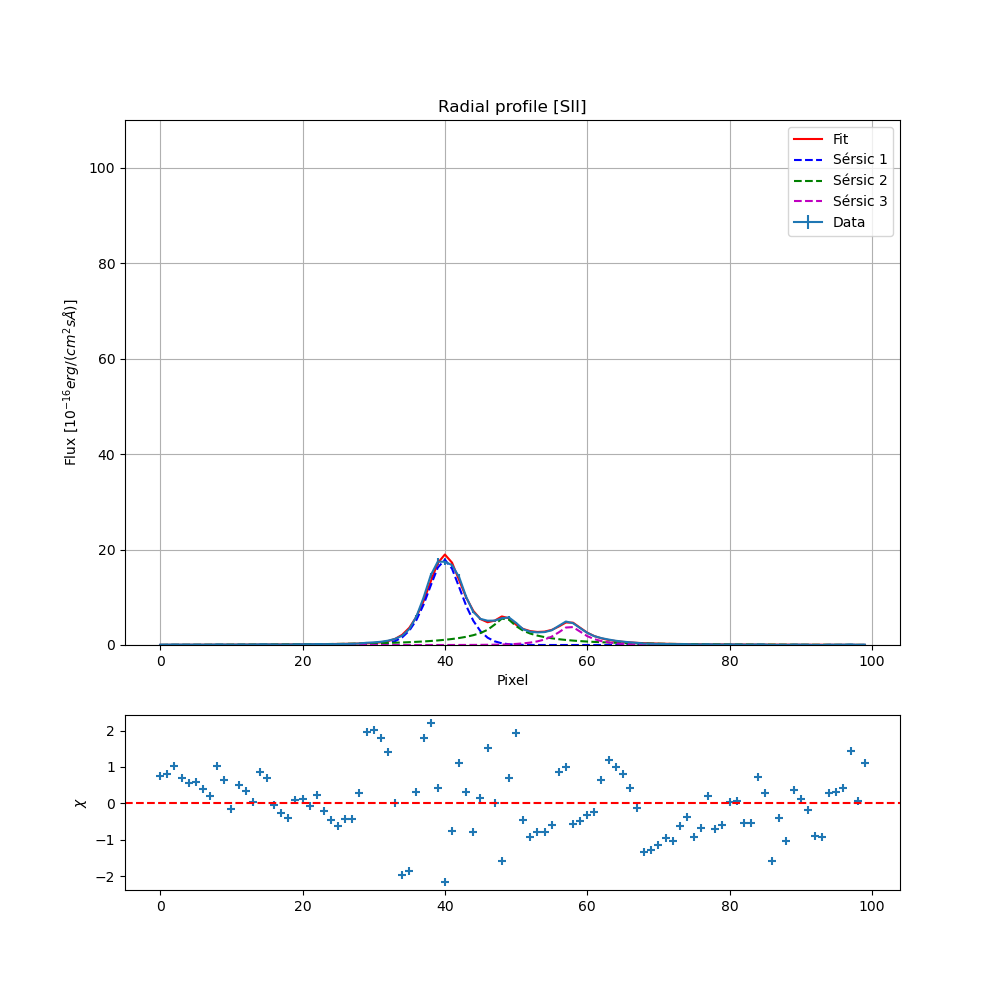

In [32]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

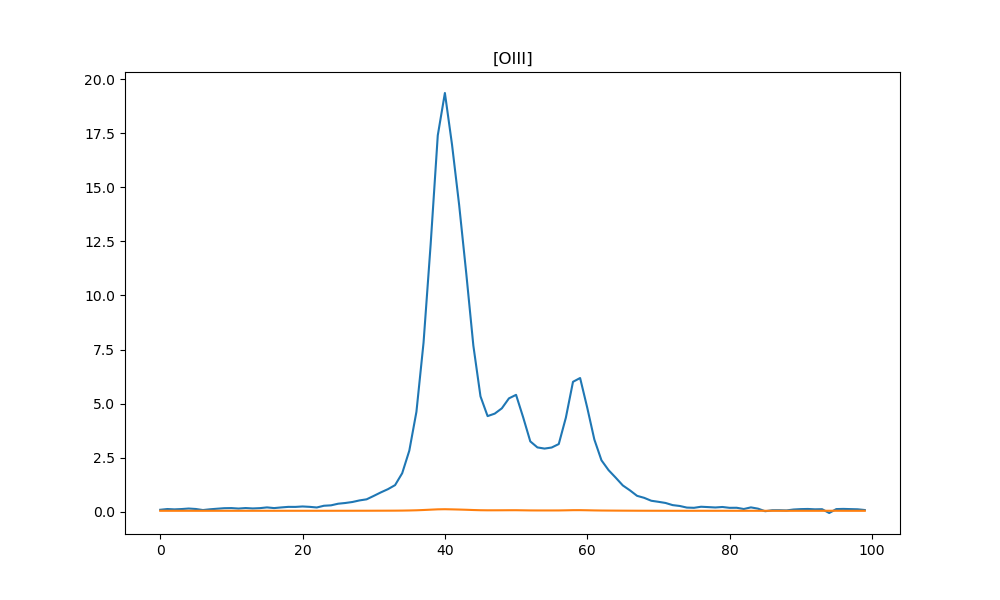

In [33]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[1])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [34]:
# Bounds:
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-0.5, x_0_HA[1]+0.5),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3615.168823071412
differential_evolution step 2: f(x)= 2361.464317758139
differential_evolution step 3: f(x)= 2361.464317758139
differential_evolution step 4: f(x)= 780.3485935309235
differential_evolution step 5: f(x)= 780.3485935309235
differential_evolution step 6: f(x)= 780.3485935309235
differential_evolution step 7: f(x)= 780.3485935309235
differential_evolution step 8: f(x)= 780.3485935309235
differential_evolution step 9: f(x)= 640.8622413005921
differential_evolution step 10: f(x)= 640.8622413005921
differential_evolution step 11: f(x)= 525.2175832198179
differential_evolution step 12: f(x)= 525.2175832198179
differential_evolution step 13: f(x)= 525.2175832198179
differential_evolution step 14: f(x)= 525.2175832198179
differential_evolution step 15: f(x)= 282.71652952204977
differential_evolution step 16: f(x)= 282.71652952204977
differential_evolution step 17: f(x)= 282.71652952204977
differential_evolution step 18: f(x)= 282.716529522049

Sérsic 1: I_e=7.6470, r_e=3.1887, n=0.6724, x_0=40.1971
Sérsic 2: I_e=1.9181, r_e=2.8942, n=0.5954, x_0=49.1095
Sérsic 3: I_e=0.2267, r_e=23.1471, n=2.1848, x_0=58.1218


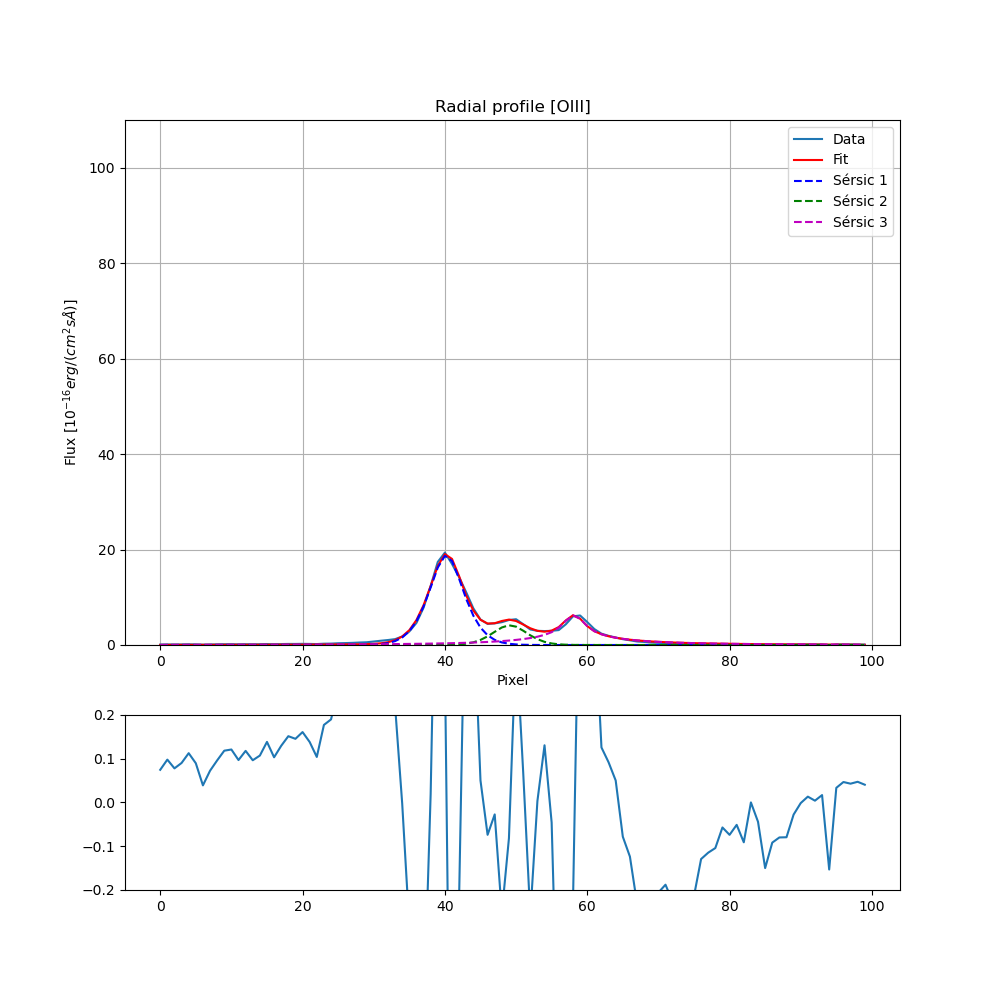

In [35]:
# Plots:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [36]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=6.7129, r_e=3.0830, n=0.7592, x_0=40.2381
Sérsic 2: I_e=0.2865, r_e=25.9080, n=1.8075, x_0=49.2017
Sérsic 3: I_e=0.8704, r_e=4.3376, n=1.2798, x_0=58.8593
[0.33046272 0.08506373 0.0419973  0.04325464 0.06048989 2.92787224
 0.14933938 0.11900179 0.16044776 0.57397493 0.14694992 0.06752259]
1.0409976044629206


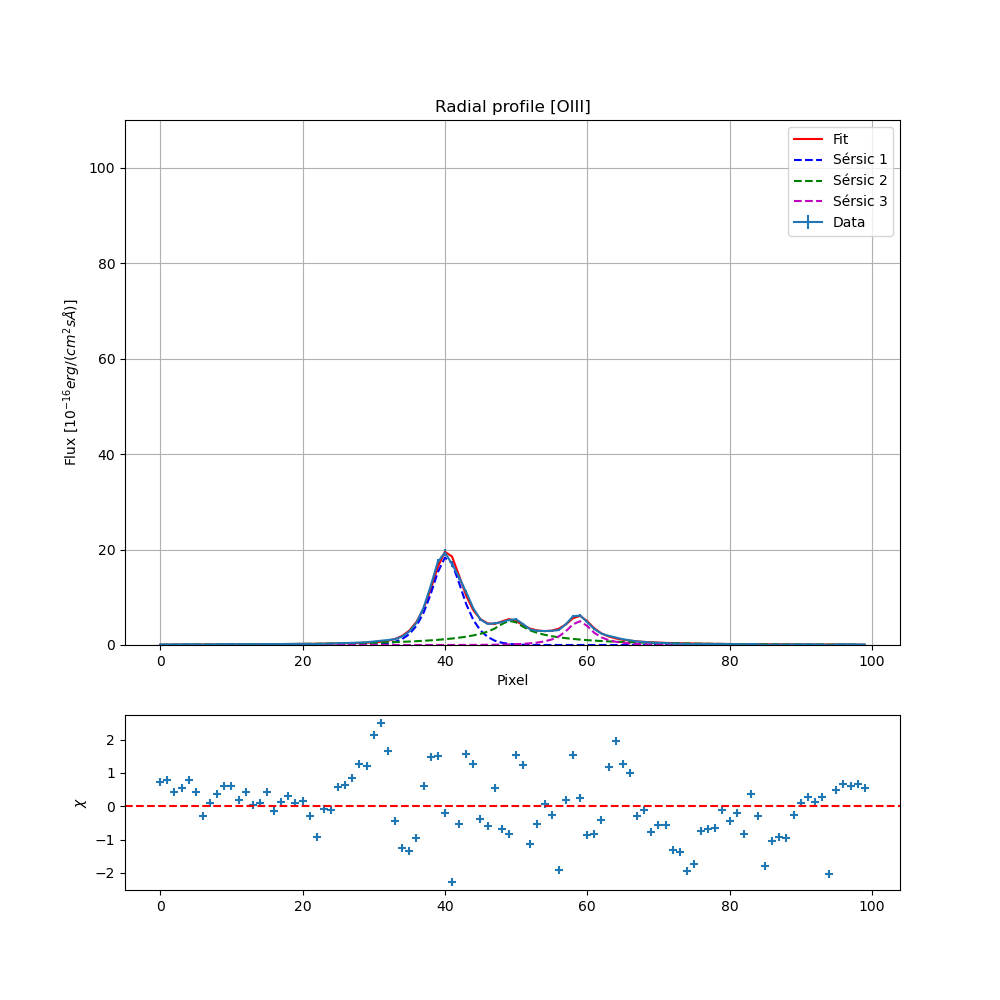

In [37]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [38]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

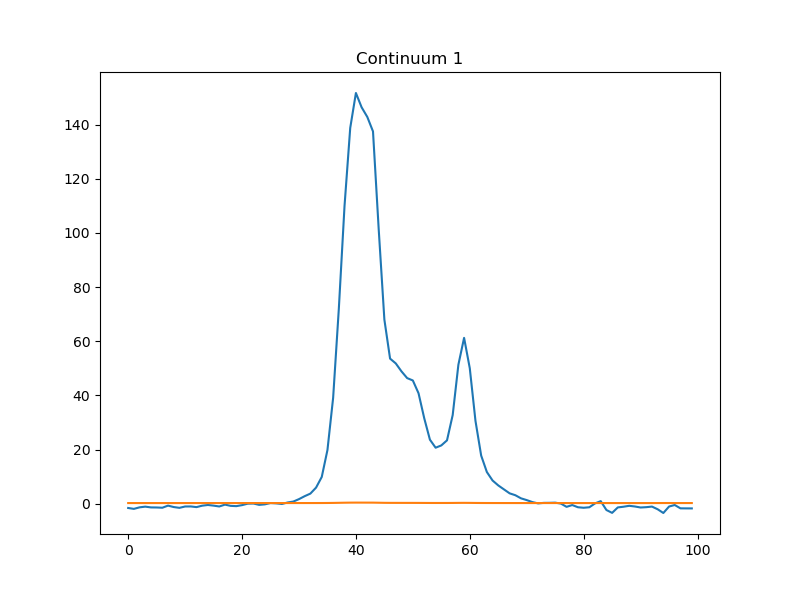

In [39]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[0])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [40]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 73514.43542158642
differential_evolution step 2: f(x)= 29992.40596076865
differential_evolution step 3: f(x)= 29992.40596076865
differential_evolution step 4: f(x)= 26639.203614937927
differential_evolution step 5: f(x)= 23065.470026656425
differential_evolution step 6: f(x)= 23065.470026656425
differential_evolution step 7: f(x)= 20122.054105127005
differential_evolution step 8: f(x)= 20122.054105127005
differential_evolution step 9: f(x)= 18980.361321145814
differential_evolution step 10: f(x)= 18161.476654129503
differential_evolution step 11: f(x)= 8112.601140505521
differential_evolution step 12: f(x)= 8112.601140505521
differential_evolution step 13: f(x)= 8112.601140505521
differential_evolution step 14: f(x)= 8112.601140505521
differential_evolution step 15: f(x)= 8112.601140505521
differential_evolution step 16: f(x)= 8112.601140505521
differential_evolution step 17: f(x)= 8112.601140505521
differential_evolution step 18: f(x)= 8112.6011405

In [41]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)    

Sérsic 1: I_e=100.0000, r_e=2.8326, n=0.3088, x_0=40.6116
Sérsic 2: I_e=10.3185, r_e=9.2287, n=1.0185, x_0=48.3863
Sérsic 3: I_e=8.9619, r_e=3.1278, n=1.4540, x_0=59.0912


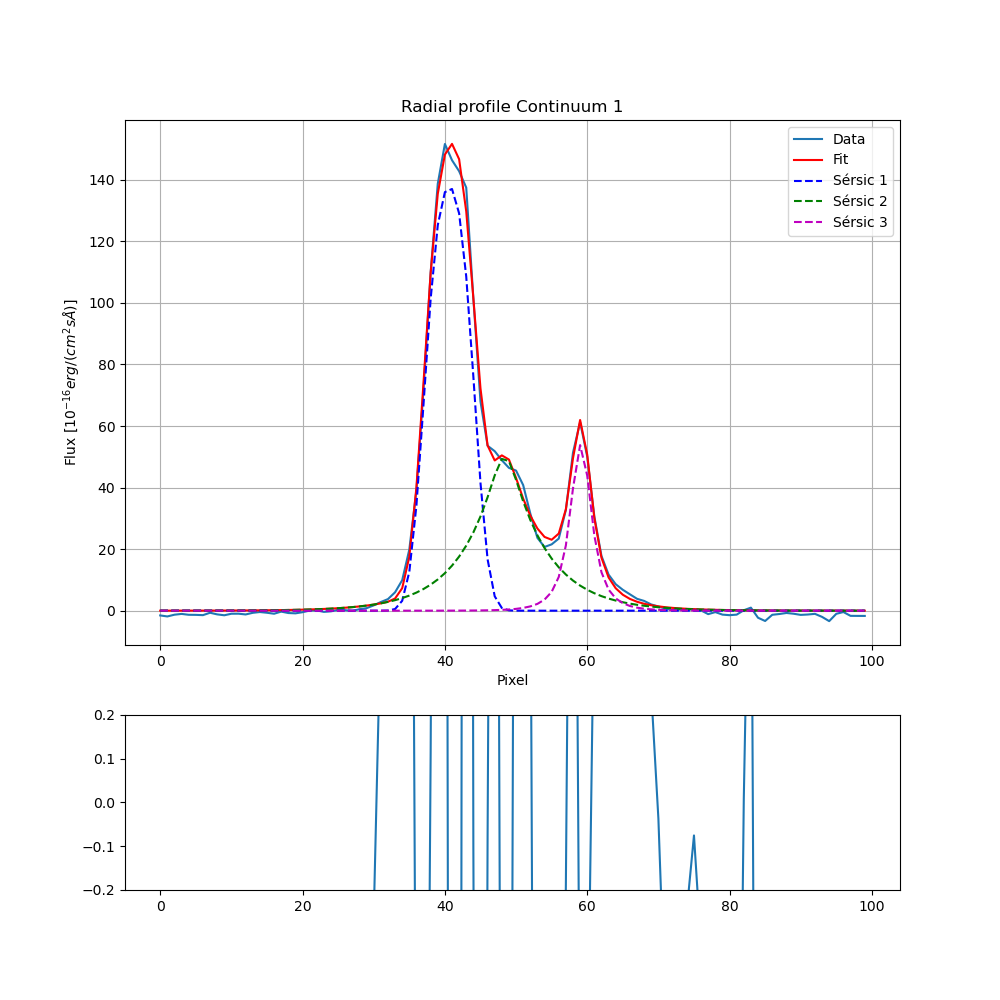

In [42]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [43]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=77.0274, r_e=3.1740, n=0.5409, x_0=40.7385
Sérsic 2: I_e=9.6601, r_e=7.3467, n=1.0261, x_0=48.8787
Sérsic 3: I_e=6.9975, r_e=4.5686, n=1.5495, x_0=59.1082
[7.55739829 0.17419308 0.07999397 0.1992471  3.06659857 1.41749949
 0.2266974  0.58609889 2.99083651 1.26055295 0.3765252  0.16465411]
13.233260171506883


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10036\2895385259.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


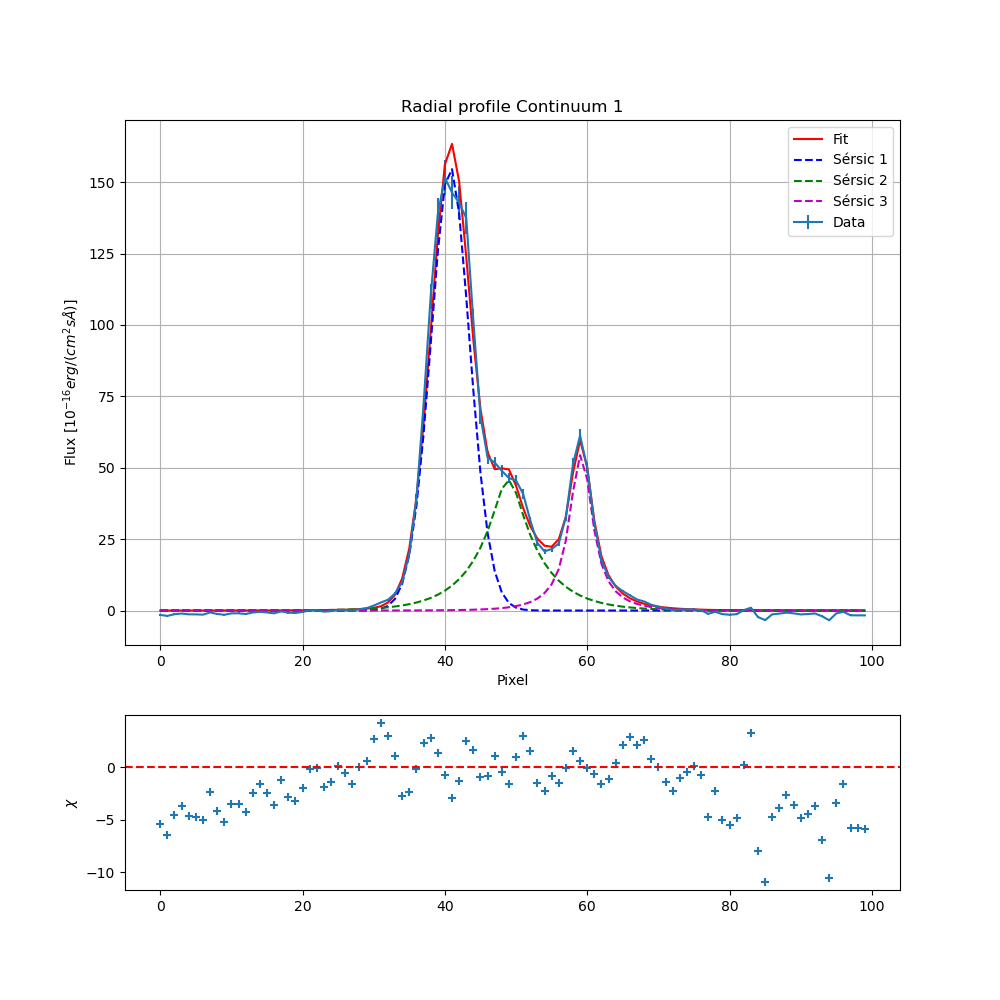

In [44]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

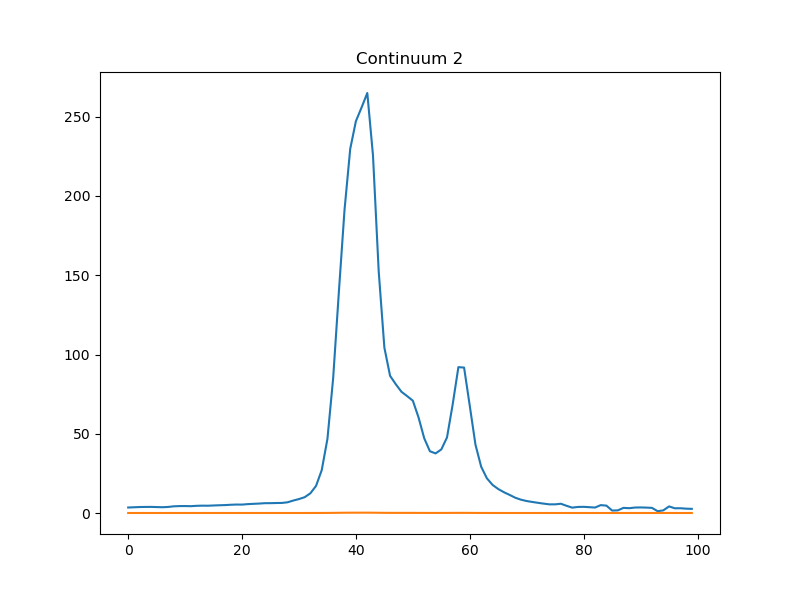

In [45]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [46]:
# Bounds:
bounds = bounds_HA
seeing_i = 3.174
sigma_i = seeing_i/ 2.35

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigma_i)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 123988.09852692975
differential_evolution step 2: f(x)= 112168.18650518455
differential_evolution step 3: f(x)= 99864.92986262147
differential_evolution step 4: f(x)= 19538.56418791987
differential_evolution step 5: f(x)= 19538.56418791987
differential_evolution step 6: f(x)= 19538.56418791987
differential_evolution step 7: f(x)= 19538.56418791987
differential_evolution step 8: f(x)= 19538.56418791987
differential_evolution step 9: f(x)= 19538.56418791987
differential_evolution step 10: f(x)= 19538.56418791987
differential_evolution step 11: f(x)= 19538.56418791987
differential_evolution step 12: f(x)= 19538.56418791987
differential_evolution step 13: f(x)= 17046.09882137794
differential_evolution step 14: f(x)= 17046.09882137794
differential_evolution step 15: f(x)= 17046.09882137794
differential_evolution step 16: f(x)= 16032.234015984173
differential_evolution step 17: f(x)= 15383.595617854637
differential_evolution step 18: f(x)= 15383.595617854

Sérsic 1: I_e=99.9999, r_e=3.8334, n=0.7381, x_0=40.7207
Sérsic 2: I_e=1.1756, r_e=49.9979, n=2.5640, x_0=49.6114
Sérsic 3: I_e=0.3258, r_e=49.9946, n=4.3887, x_0=58.4741


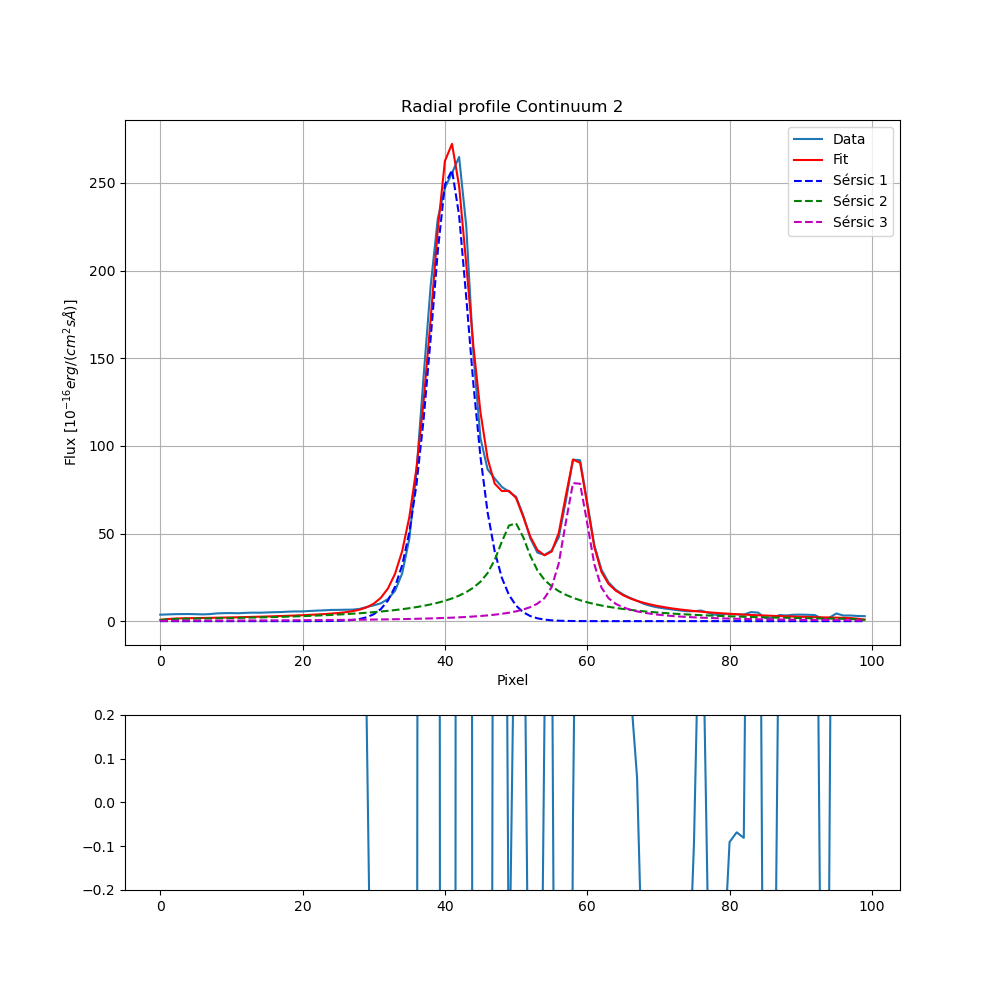

In [47]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigma_i,
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [48]:
bounds = [
    (50, 120),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 5),  # r_e: da 0.1 a 50
    (0.1, 1),  # n: da 0.1 a 10
    (38, 42),   # x_0: circa la posizione di Halpha

    (0, 5),
    (40, 70),
    (1, 3),
    (48, 52),

    (0, 1),
    (40, 70),
    (3, 5),
    (56, 60),
]
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigma_i, *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigma_i, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=119.9999, r_e=2.9841, n=0.6078, x_0=40.5713
Sérsic 2: I_e=1.3490, r_e=62.9244, n=2.6071, x_0=48.4430
Sérsic 3: I_e=0.2249, r_e=41.5571, n=4.9530, x_0=58.5236
[1.51130156e+01 1.87075228e-01 1.13692251e-01 1.88638515e-01
 1.00697080e+00 3.54699062e+01 5.40734940e-01 4.79833851e-01
 2.38616246e+00 2.79258637e+02 1.34717078e+01 2.70173437e-04]
13.076290137006275


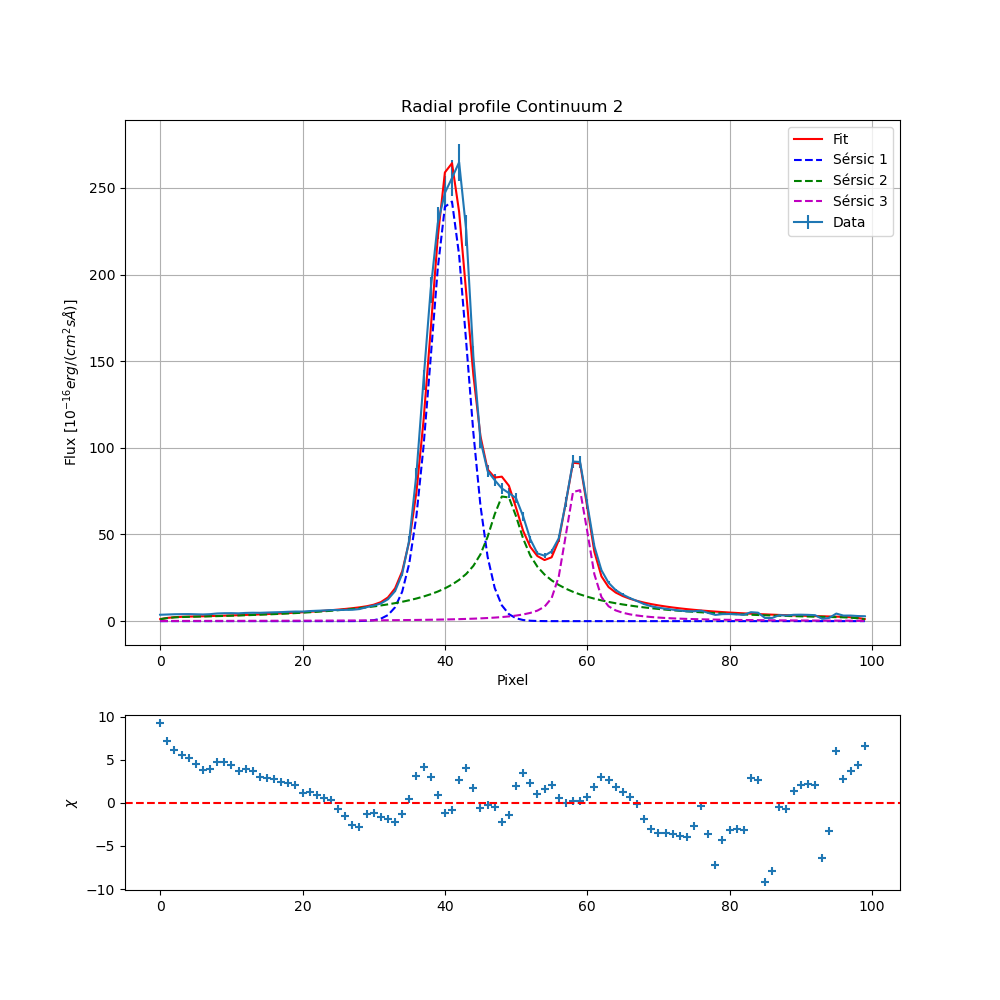

In [49]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

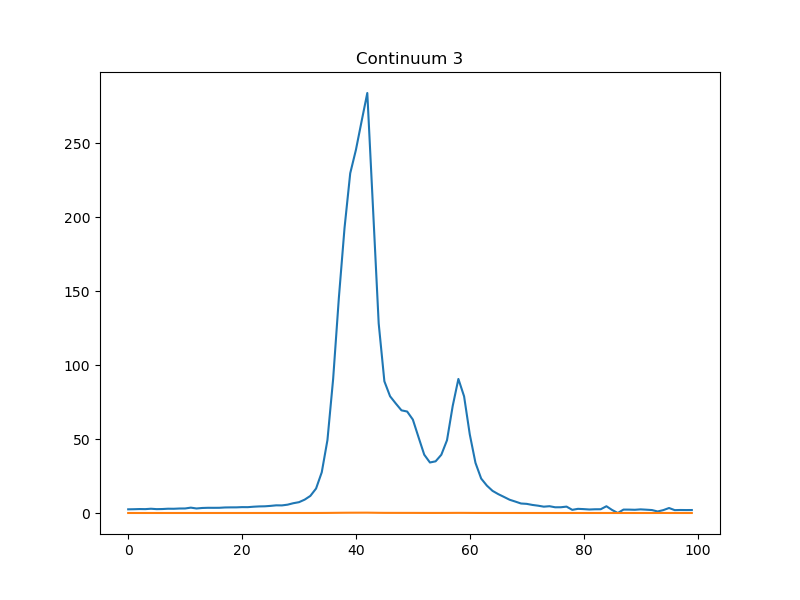

In [50]:
mask_continuum_3 = (wv > 6000)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [51]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 76825.3106333544
differential_evolution step 2: f(x)= 60201.63064598764
differential_evolution step 3: f(x)= 35589.19200221775
differential_evolution step 4: f(x)= 35589.19200221775
differential_evolution step 5: f(x)= 21921.535613255466
differential_evolution step 6: f(x)= 21921.535613255466
differential_evolution step 7: f(x)= 15330.988427854629
differential_evolution step 8: f(x)= 15330.988427854629
differential_evolution step 9: f(x)= 15330.988427854629
differential_evolution step 10: f(x)= 15330.988427854629
differential_evolution step 11: f(x)= 15330.988427854629
differential_evolution step 12: f(x)= 15330.988427854629
differential_evolution step 13: f(x)= 14985.279366445377
differential_evolution step 14: f(x)= 14985.279366445377
differential_evolution step 15: f(x)= 14985.279366445377
differential_evolution step 16: f(x)= 14985.279366445377
differential_evolution step 17: f(x)= 14985.279366445377
differential_evolution step 18: f(x)= 14985.2

Sérsic 1: I_e=100.0000, r_e=3.9662, n=0.6928, x_0=40.6212
Sérsic 2: I_e=1.2396, r_e=50.0000, n=2.3821, x_0=49.4849
Sérsic 3: I_e=11.6112, r_e=4.4155, n=1.3821, x_0=58.1838


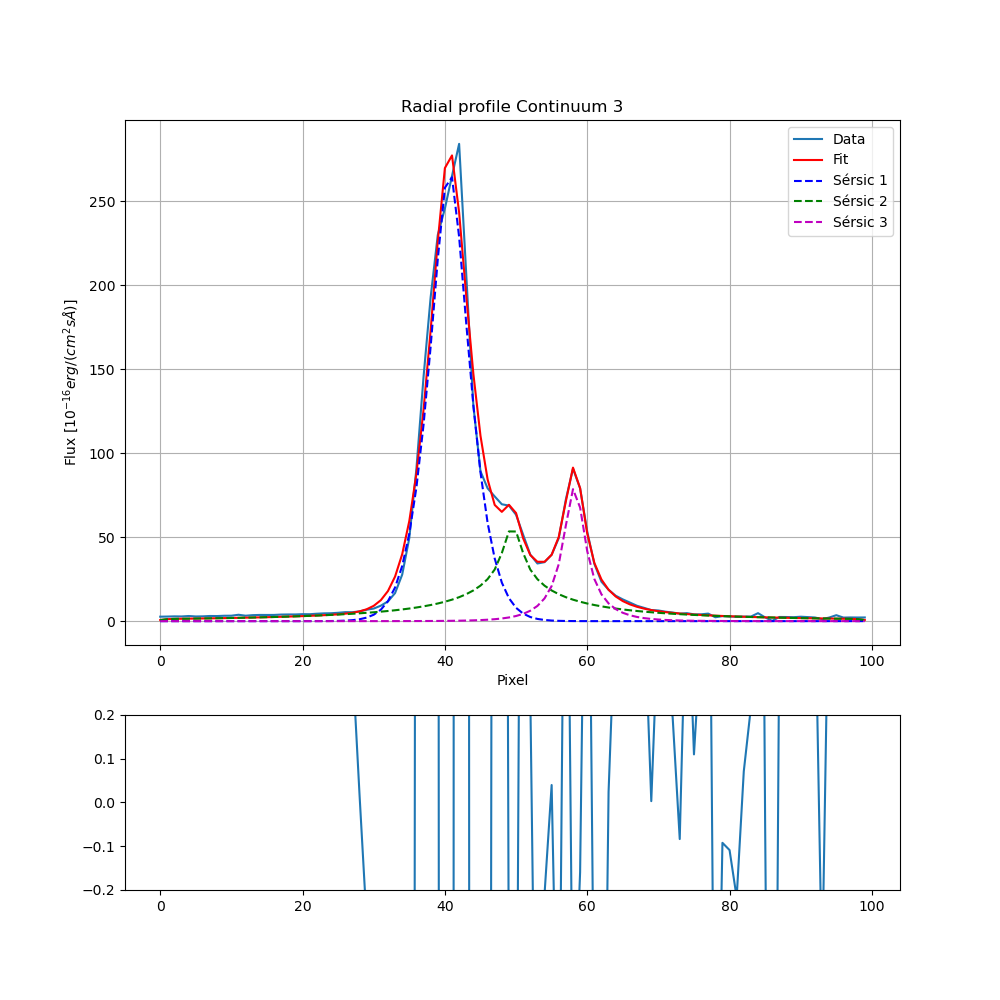

In [52]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [53]:
bounds_HA = [
    (0, 100),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (35, 43),   # x_0: posizione da 0 a 100

    (0, 20),
    (0, 50),
    (0.1, 10),
    (46, 50),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (54, 61)
]
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=100.0000, r_e=3.3778, n=0.6433, x_0=40.5163
Sérsic 2: I_e=1.5829, r_e=50.0000, n=2.3489, x_0=48.6005
Sérsic 3: I_e=14.4423, r_e=3.6500, n=1.2028, x_0=58.1784
[ 9.65173919  0.15143545  0.0788241   0.15781607  0.73341258 14.50684507
  0.33405069  0.28797984  4.36507962  0.69526401  0.26308365  0.16276009]
12.187692654089288


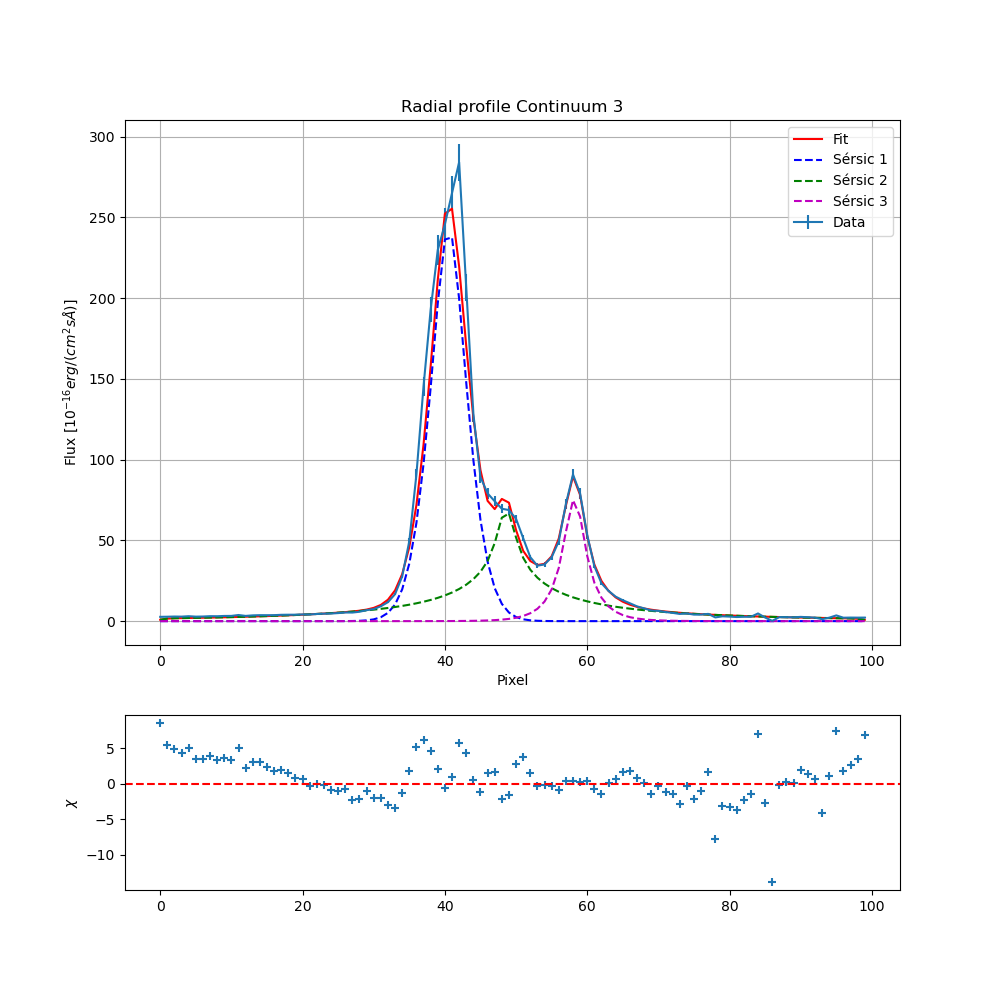

In [54]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

In [55]:
d1 = {'Name': ['Continuum 3'], 'Chi squared': chi2_continuum_3,
      'Dof': dof_continuum_3, 'Chi reduced': chi2_reduced_continuum_3}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_continuum_3.csv", index= False)

## Chi squared save

In [56]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)